In [26]:
import pandas as pd


In [27]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.dropna(inplace=True)

In [28]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer

In [30]:
from sklearn.model_selection import train_test_split

x=df.iloc[:,1:3]
y=df.iloc[:,0:1]

x_train,x_test,y_train,y_test=train_test_split(x,y)

In [31]:
x_train

,Age,Fare
85,33.0,15.850
246,25.0,7.775
58,5.0,27.750
81,29.0,9.500
818,43.0,6.450
...,...,...
592,47.0,7.250
212,22.0,7.250
342,28.0,13.000
565,24.0,24.150


In [32]:
tree=DecisionTreeClassifier()
tree.fit(x_train,y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [33]:
y_pred=tree.predict(x_test)
print('score before numerical encoding',accuracy_score(y_pred,y_test))

score before numerical encoding 0.6927374301675978


In [44]:
trf=ColumnTransformer(
    transformers=[
        ('uniform',KBinsDiscretizer(n_bins=5,encode='ordinal',strategy='uniform'),['Age','Fare'])
    ],remainder='passthrough'
)

In [54]:
x_trained_encode=trf.fit_transform(x_train)
x_test_encode=trf.fit_transform(x_test)
clums=trf.get_feature_names_out()
x_trained_encode=pd.DataFrame(x_trained_encode,columns=clums)
x_test_encode=pd.DataFrame(x_test_encode,columns=clums)

In [52]:
tree=DecisionTreeClassifier()
tree.fit(x_trained_encode,y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [55]:
y_pred_encode=tree.predict(x_test_encode)
print('score after numerical encoding',accuracy_score(y_pred_encode,y_test))

score after numerical encoding 0.6815642458100558


***creating function to work together***
encoding='ordinal','onehot'
strategy='uniform','quantile','kmeans'


In [66]:
def check(a,col,col_type):
  x=a.iloc[:,1:3]
  y=a.iloc[:,0:1]

  x_train,x_test,y_train,y_test=train_test_split(x,y)
  tree=DecisionTreeClassifier()
  tree.fit(x_train,y_train)
  y_pred=tree.predict(x_test)
  print('score before numerical encoding',accuracy_score(y_pred,y_test))

  trf=ColumnTransformer(
    transformers=[
        (col,KBinsDiscretizer(n_bins=5,encode=col_type,strategy=col),['Age','Fare'])
    ],remainder='passthrough'
   )
  x_trained_encode=trf.fit_transform(x_train)
  x_test_encode=trf.fit_transform(x_test)
  clums=trf.get_feature_names_out()
  x_trained_encode=pd.DataFrame(x_trained_encode,columns=clums)
  x_test_encode=pd.DataFrame(x_test_encode,columns=clums)
  tree=DecisionTreeClassifier()
  tree.fit(x_trained_encode,y_train)
  y_pred_encode=tree.predict(x_test_encode)
  print('score after numerical encoding',accuracy_score(y_pred_encode,y_test))

In [92]:
import seaborn as sns

***checkng impact of spreading of data by binning (uniform,quantile)***
  quantile impacts spres in uniform way whilev donot have any impact on spread data
  

In [84]:
import scipy.stats as stats
import matplotlib.pyplot as plp

In [94]:
x_trained_encode

,uniform__Age,uniform__Fare
0,2.0,0.0
1,1.0,0.0
2,0.0,0.0
3,1.0,0.0
4,2.0,0.0
...,...,...
530,2.0,0.0
531,1.0,0.0
532,1.0,0.0
533,1.0,0.0


In [144]:
def check(a,col,col_type):
  x=a.iloc[:,1:3]
  y=a.iloc[:,0:1]

  x_train,x_test,y_train,y_test=train_test_split(x,y)
  tree=DecisionTreeClassifier()
  tree.fit(x_train,y_train)
  y_pred=tree.predict(x_test)
  print('score before numerical encoding',accuracy_score(y_pred,y_test))

  trf=ColumnTransformer(
    transformers=[
        (col,KBinsDiscretizer(n_bins=5,encode=col_type,strategy=col),['Age','Fare'])
    ],remainder='passthrough'
   )
  x_trained_encode=trf.fit_transform(x_train)
  x_test_encode=trf.fit_transform(x_test)
  # clums=trf.get_feature_names_out()
  # x_trained_encode=pd.DataFrame(x_trained_encode,columns=clums)
  # x_test_encode=pd.DataFrame(x_test_encode,columns=clums)
  tree=DecisionTreeClassifier()
  tree.fit(x_trained_encode,y_train)
  y_pred_encode=tree.predict(x_test_encode)
  print('score after numerical encoding',accuracy_score(y_pred_encode,y_test))
  fig,(ax1,ax2)=plp.subplots(1,2,figsize=(10,5))
  ax1.set_title('before encoding data spread')
  sns.kdeplot(x_train['Age'],ax=ax1)
  sns.kdeplot(x_train['Fare'],ax=ax1)
  ax2.set_title('after encoding data spread')
  sns.kdeplot(x_trained_encode[0],ax=ax2)
  sns.kdeplot(x_trained_encode[1],ax=ax2)
  plp.show()

score before numerical encoding 0.6256983240223464
score after numerical encoding 0.6089385474860335


/tmp/ipykernel_5278/1583554479.py:30: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(x_trained_encode[0],ax=ax2)


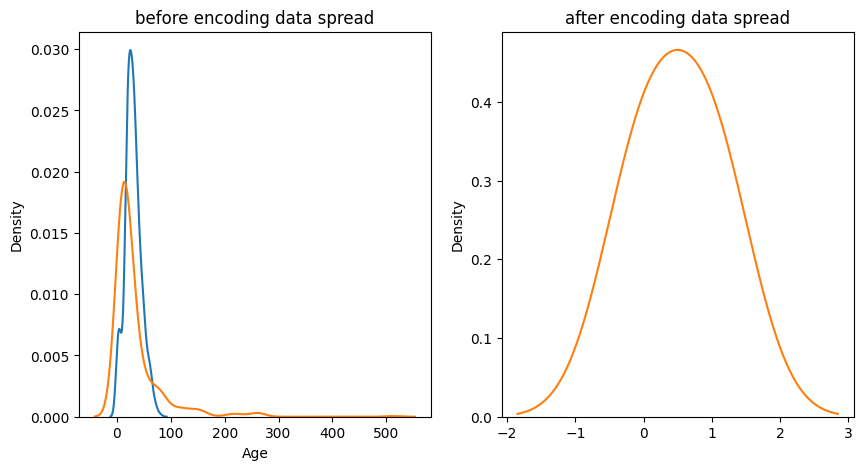

In [145]:
check(df,'uniform','ordinal')


score before numerical encoding 0.5977653631284916
score after numerical encoding 0.659217877094972


/home/linuxbrew/.linuxbrew/Cellar/jupyterlab/4.5.3/libexec/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/home/linuxbrew/.linuxbrew/Cellar/jupyterlab/4.5.3/libexec/lib/python3.14/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/tmp/ipykernel_5278/1583554479.py:30: UserWarning: Dataset has 0 variance; skipp

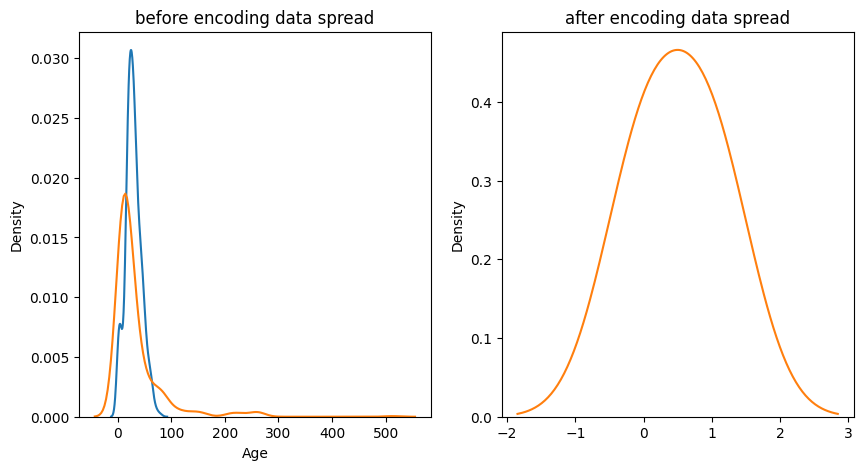

In [146]:
check(df,'quantile','ordinal')

,uniform__Age,uniform__Fare
0,2.0,0.0
1,1.0,0.0
2,0.0,0.0
3,1.0,0.0
4,2.0,0.0
...,...,...
530,2.0,0.0
531,1.0,0.0
532,1.0,0.0
533,1.0,0.0


In [124]:
dff=pd.read_csv('train.csv',usecols=['Survived','Age','SibSp','Parch','Fare'])
dff['family']=dff['SibSp']+dff['Parch']
dff.head()

,Survived,Age,SibSp,Parch,Fare,family
0,0,22.0,1,0,7.2500,1
1,1,38.0,1,0,71.2833,1
2,1,26.0,0,0,7.9250,0
3,1,35.0,1,0,53.1000,1
4,0,35.0,0,0,8.0500,0


,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [134]:
from sklearn.preprocessing import Binarizer

In [143]:
x__train

NameError: name 'x__train' is not defined

def check(a):
  x=a.drop(['Age'],axis=1)
  y=dff[['Survived']]
  x__train,x__test,y__train,y__test=train_test_split(x,y)
  tree=DecisionTreeClassifier()
  tree.fit(x__train,y__train)
  y__pred=tree.predict(x__test)
  print('score before binerization',accuracy_score(y_pred,y_test))

  trf=ColumnTransformer(
    transformers=[
        ('bin',Binarizer(copy=False),['Family'])
    ],remainder='passthrough'
   )
  x__trained_encode=trf.fit_transform(x__train)
  x__test_encode=trf.fit_transform(x__test)
  # clums=trf.get_feature_names_out()
  # x_trained_encode=pd.DataFrame(x_trained_encode,columns=clums)
  # x_test_encode=pd.DataFrame(x_test_encode,columns=clums)
  tree=DecisionTreeClassifier()
  tree.fit(x__trained_encode,y__train)
  y__pred_encode=tree.predict(x__test_encode)
  print('score after numerical encoding',accuracy_score(y_pred_encode,y_test))
  fig,(ax1,ax2)=plp.subplots(1,2,figsize=(10,5))
  ax1.set_title('before encoding data spread')
  sns.kdeplot(x_train['Age'],ax=ax1)
  sns.kdeplot(x_train['Fare'],ax=ax1)
  ax2.set_title('after encoding data spread')
  sns.kdeplot(x_trained_encode[0],ax=ax2)
  sns.kdeplot(x_trained_encode[1],ax=ax2)
  plp.show()

In [141]:
check(dff)

score before binerization 0.6927374301675978


ValueError: A given column is not a column of the dataframe

In [139]:
x_train

,Age,Fare
85,33.0,15.850
246,25.0,7.775
58,5.0,27.750
81,29.0,9.500
818,43.0,6.450
...,...,...
592,47.0,7.250
212,22.0,7.250
342,28.0,13.000
565,24.0,24.150
